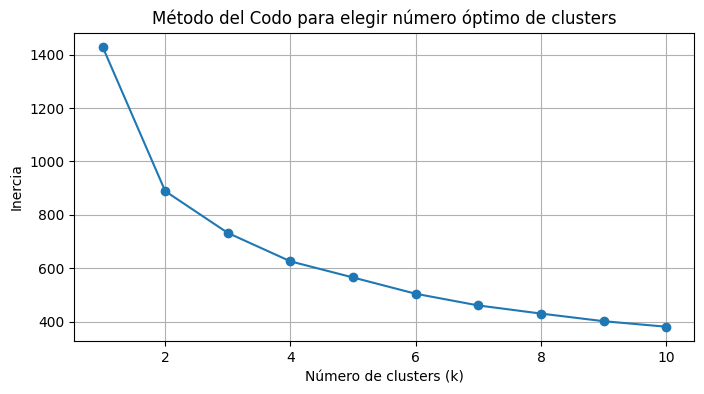

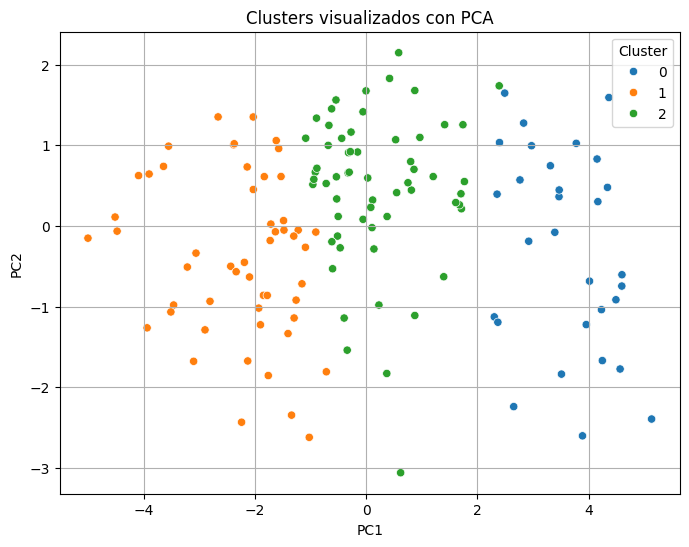

In [3]:
# 1. Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Cargar el dataset con codificación adecuada (sin 'errors')
df = pd.read_csv("Osos.csv", encoding='utf-16')

# 3. Preprocesamiento: seleccionar solo variables numéricas
X = df.select_dtypes(include='number')

# 4. Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Método del codo para determinar número óptimo de clusters
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 6. Visualización del codo
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo para elegir número óptimo de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# 7. Ajustar modelo KMeans con k óptimo (ajustar este valor según el codo)
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 8. Añadir resultados al dataframe
df['Cluster'] = clusters

# 9. Visualización con PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='tab10')
plt.title('Clusters visualizados con PCA')
plt.grid(True)
plt.show()


In [4]:
cluster_means = df.groupby('Cluster')[X.columns].mean()
display(cluster_means)

,ID,Mes,Sexo,L.Cabeza,A.Cabeza,C.Pescuezo,Longitud,C.Pecho,Peso,No.Obs
Cluster,,,,,,,,,,
0,403.033333,7.900000,1.000000,16.000000,8.083333,29.010000,73.633333,48.300000,367.400000,1.366667
1,529.038462,7.307692,1.557692,11.653846,5.192308,16.711538,52.461538,28.798077,99.288462,1.230769
2,562.786885,8.672131,1.245902,13.647541,6.439344,21.483607,62.727869,36.824590,185.147541,1.819672


Based on the mean values of the numerical features within each cluster, we can now interpret what distinguishes the clusters. For example, looking at the 'Peso' (Weight) column in the `cluster_means` table above:

- **Cluster 1**: Has the lowest average weight, suggesting these are the **small bears**.
- **Cluster 2**: Has a medium average weight, suggesting these are the **medium bears**.
- **Cluster 0**: Has the highest average weight, suggesting these are the **large bears**.

We can verify this by looking at other features like 'Longitud' (Length) and 'C.Pecho' (Chest Circumference).

Now, let's add a column to the original DataFrame to label each bear with its size category.

In [5]:
def assign_size_category(cluster):
    if cluster == 1:
        return 'Pequeño'
    elif cluster == 2:
        return 'Mediano'
    elif cluster == 0:
        return 'Grande'
    else:
        return 'Desconocido'

df['Tamaño'] = df['Cluster'].apply(assign_size_category)

display(df[['ID', 'Cluster', 'Tamaño', 'Peso', 'Longitud', 'C.Pecho']].head())

,ID,Cluster,Tamaño,Peso,Longitud,C.Pecho
0,39,1,Pequeño,65,45.0,23.0
1,41,1,Pequeño,70,47.5,24.0
2,41,1,Pequeño,74,57.0,27.0
3,41,2,Mediano,142,59.5,38.0
4,41,1,Pequeño,121,62.0,31.0
